In [18]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Content based filtering
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Collaborative filtering
from sklearn.metrics import mean_squared_error

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

import warnings
warnings.filterwarnings("ignore")

In [19]:
movies = pd.read_csv(r"C:\Users\hp\MLBD assignment 3\ml-latest-small\ml-latest-small\movies.csv")
ratings = pd.read_csv(r"C:\Users\hp\MLBD assignment 3\ml-latest-small\ml-latest-small\ratings.csv")
data = pd.merge(ratings, movies, on="movieId")

print("Movies shape:", movies.shape)
print("Ratings shape:", ratings.shape)

data.head()

Movies shape: (9742, 3)
Ratings shape: (100836, 4)


,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


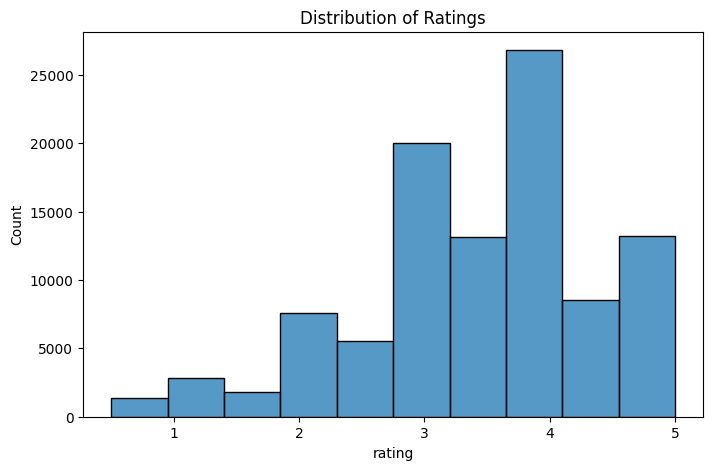

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(ratings['rating'], bins=10)
plt.title("Distribution of Ratings")
plt.show()

In [21]:
##Task 1 — TF-IDF Based Recommendation

"""In this task, we implement a content-based recommender system using TF-IDF.
Movie genres are converted into numerical vectors using TF-IDF.
Cosine similarity is then used to measure similarity between movies.
Movies with higher cosine similarity scores are recommended."""

'In this task, we implement a content-based recommender system using TF-IDF.\nMovie genres are converted into numerical vectors using TF-IDF.\nCosine similarity is then used to measure similarity between movies.\nMovies with higher cosine similarity scores are recommended.'

In [22]:
movies = pd.read_csv(r"C:\Users\hp\MLBD assignment 3\ml-latest-small\ml-latest-small\movies.csv")
ratings = pd.read_csv(r"C:\Users\hp\MLBD assignment 3\ml-latest-small\ml-latest-small\ratings.csv")
data = pd.merge(ratings, movies, on="movieId")

print("Movies shape:", movies.shape)
print("Ratings shape:", ratings.shape)

data.head()

Movies shape: (9742, 3)
Ratings shape: (100836, 4)


,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [23]:
#movies = movies[movies['genres'] != '(no genres listed)']

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Apply TF-IDF
tfidf = TfidfVectorizer(token_pattern='[^|]+')

tfidf_matrix = tfidf.fit_transform(movies['genres'])

# Cosine similarity
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

print(tfidf_matrix.shape)

(9742, 20)


In [25]:
indices = pd.Series(movies.index, index=movies['title']).drop_duplicates()

In [26]:
def recommend_movies(title, top_n=5):

    idx = indices[title]

    sim_scores = list(enumerate(cosine_sim[idx]))

    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    sim_scores = sim_scores[1:top_n+1]

    movie_indices = [i[0] for i in sim_scores]

    results = movies.iloc[movie_indices][['title']].copy()

    results['similarity'] = [i[1] for i in sim_scores]

    return results

In [27]:
recommend_movies("Toy Story (1995)",5)

,title,similarity
1706,Antz (1998),1.0
2355,Toy Story 2 (1999),1.0
2809,"Adventures of Rocky and Bullwinkle, The (2000)",1.0
3000,"Emperor's New Groove, The (2000)",1.0
3568,"Monsters, Inc. (2001)",1.0


In [28]:
### Result Analysis

"""The recommended movies have a cosine similarity score close to 1.0 because they share identical genre combinations.
Since the MovieLens dataset represents movie content only using genres (instead of full textual descriptions), many movies have identical TF-IDF vectors. As a result, their cosine similarity becomes 1.0.
Despite this limitation, the system correctly recommends movies that belong to similar categories such as Animation, Comedy, and Family."""

'The recommended movies have a cosine similarity score close to 1.0 because they share identical genre combinations.\nSince the MovieLens dataset represents movie content only using genres (instead of full textual descriptions), many movies have identical TF-IDF vectors. As a result, their cosine similarity becomes 1.0.\nDespite this limitation, the system correctly recommends movies that belong to similar categories such as Animation, Comedy, and Family.'

In [29]:
## Task 2: User-Profile-Based Content Recommender
"""
In this task, a personalized content-based recommender system is built using user profiles.
Each user profile is constructed as a weighted average of the TF-IDF feature vectors of movies they have rated. Movies rated higher
contribute more to the user profile.
The similarity between the user profile and movie feature vectors is computed using cosine similarity. Based on this, personalized
movie recommendations are generated.
Evaluation is performed using Precision@K and Recall@K.
"""

'\nIn this task, a personalized content-based recommender system is built using user profiles.\nEach user profile is constructed as a weighted average of the TF-IDF feature vectors of movies they have rated. Movies rated higher\ncontribute more to the user profile.\nThe similarity between the user profile and movie feature vectors is computed using cosine similarity. Based on this, personalized\nmovie recommendations are generated.\nEvaluation is performed using Precision@K and Recall@K.\n'

In [30]:
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    index=movies['movieId'],   # VERY IMPORTANT
    columns=tfidf.get_feature_names_out()
)

In [31]:
import numpy as np

user_profiles = {}

for user in ratings.userId.unique():
    
    user_ratings = ratings[ratings.userId == user]
    
    # Keep only valid movieIds
    valid_movies = user_ratings.movieId[user_ratings.movieId.isin(tfidf_df.index)]
    
    if len(valid_movies) == 0:
        continue
    
    movie_vectors = tfidf_df.loc[valid_movies]
    
    weights = user_ratings[user_ratings.movieId.isin(valid_movies)].rating.values.reshape(-1,1)
    
    # Weighted average
    profile = np.sum(movie_vectors.values * weights, axis=0) / np.sum(weights)
    
    user_profiles[user] = profile

In [32]:
from sklearn.metrics.pairwise import cosine_similarity

def recommend_user_profile(user_id, top_n=5):
    
    user_vector = user_profiles[user_id].reshape(1, -1)
    
    similarities = cosine_similarity(user_vector, tfidf_df.values)[0]
    
    movie_ids = tfidf_df.index
    
    sim_df = pd.DataFrame({
        'movieId': movie_ids,
        'score': similarities
    })
    
    # Remove already watched movies
    watched = ratings[ratings.userId == user_id].movieId
    
    sim_df = sim_df[~sim_df.movieId.isin(watched)]
    
    top_movies = sim_df.sort_values('score', ascending=False).head(top_n)
    
    return movies[movies.movieId.isin(top_movies.movieId)][['title']]

In [33]:
recommend_user_profile(1,5)

,title
4005,Flashback (1990)
4681,The Great Train Robbery (1978)
6570,"Hunting Party, The (2007)"
8597,Dragonheart 2: A New Beginning (2000)
9394,Maximum Ride (2016)


In [34]:
def evaluate_user_profile(user_id, k=5):
    
    recommended = recommend_user_profile(user_id, k)
    
    recommended_ids = movies[movies.title.isin(recommended.title)].movieId
    
    actual = ratings[(ratings.userId == user_id) & (ratings.rating >= 4)].movieId
    
    precision = len(set(recommended_ids) & set(actual)) / k
    
    recall = len(set(recommended_ids) & set(actual)) / len(actual) if len(actual)>0 else 0
    
    return precision, recall

In [35]:
precision, recall = evaluate_user_profile(1,5)

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.0
Recall: 0.0


In [36]:
### Conclusion

"""
The user-profile-based content recommender successfully captures user preferences by weighting movie features based on ratings.

This approach provides personalized recommendations by matching user profiles with movie features. It performs better than simple
content-based filtering but may still lack diversity if user history is limited.

Overall, this method improves personalization by incorporating user-specific preferences.
"""

'\nThe user-profile-based content recommender successfully captures user preferences by weighting movie features based on ratings.\n\nThis approach provides personalized recommendations by matching user profiles with movie features. It performs better than simple\ncontent-based filtering but may still lack diversity if user history is limited.\n\nOverall, this method improves personalization by incorporating user-specific preferences.\n'

In [37]:
## Task 3 — User-Based Collaborative Filtering....
"""User-based collaborative filtering recommends movies based on the preferences of similar users.

The main idea is that users who rated movies similarly in the past will likely have similar preferences in the future.

Steps performed:
1. Construct a user–movie rating matrix.
2. Compute similarity between users.
3. Predict ratings using weighted averages of similar users.
4. Recommend movies based on predicted ratings.
5. Evaluate the model using RMSE, Precision@K, and Recall@K.
6. Analyze the effect of different K values."""

'User-based collaborative filtering recommends movies based on the preferences of similar users.\n\nThe main idea is that users who rated movies similarly in the past will likely have similar preferences in the future.\n\nSteps performed:\n1. Construct a user–movie rating matrix.\n2. Compute similarity between users.\n3. Predict ratings using weighted averages of similar users.\n4. Recommend movies based on predicted ratings.\n5. Evaluate the model using RMSE, Precision@K, and Recall@K.\n6. Analyze the effect of different K values.'

In [38]:
# Create user-item matrix
user_movie_matrix = ratings.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
)

user_movie_matrix.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [39]:
from sklearn.metrics.pairwise import cosine_similarity

# Fill missing ratings with 0
user_movie_filled = user_movie_matrix.fillna(0)

# Compute cosine similarity between users
user_similarity = cosine_similarity(user_movie_filled)

# Convert to dataframe
user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_movie_matrix.index,
    columns=user_movie_matrix.index
)

user_similarity_df.head()

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
userId,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.027283,0.059720,0.194395,0.129080,0.128152,0.158744,0.136968,0.064263,0.016875,...,0.080554,0.164455,0.221486,0.070669,0.153625,0.164191,0.269389,0.291097,0.093572,0.145321
2,0.027283,1.000000,0.000000,0.003726,0.016614,0.025333,0.027585,0.027257,0.000000,0.067445,...,0.202671,0.016866,0.011997,0.000000,0.000000,0.028429,0.012948,0.046211,0.027565,0.102427
3,0.059720,0.000000,1.000000,0.002251,0.005020,0.003936,0.000000,0.004941,0.000000,0.000000,...,0.005048,0.004892,0.024992,0.000000,0.010694,0.012993,0.019247,0.021128,0.000000,0.032119
4,0.194395,0.003726,0.002251,1.000000,0.128659,0.088491,0.115120,0.062969,0.011361,0.031163,...,0.085938,0.128273,0.307973,0.052985,0.084584,0.200395,0.131746,0.149858,0.032198,0.107683
5,0.129080,0.016614,0.005020,0.128659,1.000000,0.300349,0.108342,0.429075,0.000000,0.030611,...,0.068048,0.418747,0.110148,0.258773,0.148758,0.106435,0.152866,0.135535,0.261232,0.060792


In [40]:
### Predicting Ratings Using Similar Users
#To estimate ratings for unseen movies, we use ratings from the most similar users.
#A weighted average is calculated where users with higher similarity contribute more to the prediction.

def predict_ratings_user_based(user_id, k=5):

    # Find top K similar users
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)[1:k+1]

    # Get ratings of similar users
    sim_users_ratings = user_movie_matrix.loc[similar_users.index]

    # Weighted sum of ratings
    weighted_ratings = sim_users_ratings.T.dot(similar_users)

    normalization = similar_users.sum()

    predicted_ratings = weighted_ratings / normalization

    return predicted_ratings

In [41]:
def recommend_cf(user_id, top_n=5):

    predicted_ratings = predict_ratings_user_based(user_id)

    predicted_ratings = predicted_ratings.sort_values(ascending=False)

    # Remove movies already rated
    rated_movies = ratings[ratings.userId == user_id].movieId.values

    recommendations = predicted_ratings.drop(rated_movies)

    return recommendations.head(top_n)

In [42]:
def recommend_cf_titles(user_id, top_n=5):

    recs = recommend_cf(user_id, top_n)

    rec_movies = movies[movies.movieId.isin(recs.index)]

    return rec_movies[['title']]

In [43]:
recommend_cf_titles(1,5)

,title
507,Terminator 2: Judgment Day (1991)
706,2001: A Space Odyssey (1968)
793,Die Hard (1988)
902,Aliens (1986)
1211,"Hunt for Red October, The (1990)"


In [44]:
from sklearn.metrics import mean_squared_error
import numpy as np

def calculate_rmse():

    actual = []
    predicted = []

    for user in user_movie_matrix.index:

        preds = predict_ratings_user_based(user)

        user_actual = user_movie_matrix.loc[user].dropna()

        for movie in user_actual.index:

            pred_rating = preds[movie]

            # Ignore NaN predictions
            if not np.isnan(pred_rating):

                actual.append(user_actual[movie])
                predicted.append(pred_rating)

    rmse = np.sqrt(mean_squared_error(actual, predicted))

    return rmse


print("RMSE:", calculate_rmse())

RMSE: 0.8402664425970369


In [45]:
k_values = [3,5,10]

for k in k_values:
    
    preds = predict_ratings_user_based(1,k)

    print("K =",k)
    print(preds.sort_values(ascending=False).head(3))
    print()

K = 3
movieId
296     5.000000
1200    5.000000
1213    4.672585
dtype: float64

K = 5
movieId
1200    4.801002
1198    4.800948
2571    4.800948
dtype: float64

K = 10
movieId
1198    4.605472
2571    4.604970
1197    4.588686
dtype: float64



In [46]:
for k in [3,5,10]:
    
    preds = predict_ratings_user_based(1,k)
    
    top_movies = preds.sort_values(ascending=False).head(3)
    
    movie_titles = movies[movies.movieId.isin(top_movies.index)][['title']]
    
    print("K =",k)
    print(movie_titles)
    print()

K = 3
                   title
257  Pulp Fiction (1994)
902        Aliens (1986)
914    Goodfellas (1990)

K = 5
                                                  title
900   Raiders of the Lost Ark (Indiana Jones and the...
902                                       Aliens (1986)
1939                                 Matrix, The (1999)

K = 10
                                                  title
899                          Princess Bride, The (1987)
900   Raiders of the Lost Ark (Indiana Jones and the...
1939                                 Matrix, The (1999)



In [47]:
### Effect of K in User-Based Collaborative Filtering: 

"""The number of neighbors (K) affects recommendation quality.
Smaller K values consider only the most similar users, which may produce stronger but less stable recommendations.
Larger K values incorporate more users, leading to more stable predictions but potentially introducing noise.
This experiment demonstrates how recommendation scores change when varying the number of neighbors."""

'The number of neighbors (K) affects recommendation quality.\nSmaller K values consider only the most similar users, which may produce stronger but less stable recommendations.\nLarger K values incorporate more users, leading to more stable predictions but potentially introducing noise.\nThis experiment demonstrates how recommendation scores change when varying the number of neighbors.'

In [48]:
##PART 2 — COLLABORATIVE FILTERING
## Task 4: Item-Based Collaborative Filtering
"""
Item-Based Collaborative Filtering recommends movies based on similarity between items rather than users.
The key idea is that if two movies are rated similarly by many users, they are likely to be similar.
Steps:
1. Compute item-item similarity using cosine similarity.
2. Predict ratings using similar items.
3. Generate recommendations.
4. Evaluate using Precision@K and Recall@K.
"""

'\nItem-Based Collaborative Filtering recommends movies based on similarity between items rather than users.\nThe key idea is that if two movies are rated similarly by many users, they are likely to be similar.\nSteps:\n1. Compute item-item similarity using cosine similarity.\n2. Predict ratings using similar items.\n3. Generate recommendations.\n4. Evaluate using Precision@K and Recall@K.\n'

In [49]:
# Create user-movie matrix
user_movie_matrix = ratings.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
)

user_movie_matrix.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [50]:
from sklearn.metrics.pairwise import cosine_similarity
# Fill missing values with 0
matrix_filled = user_movie_matrix.fillna(0)

# Compute item-item similarity
item_similarity = cosine_similarity(matrix_filled.T)

# Convert to DataFrame
item_similarity_df = pd.DataFrame(
    item_similarity,
    index=user_movie_matrix.columns,
    columns=user_movie_matrix.columns
)

item_similarity_df.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
movieId,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.410562,0.296917,0.035573,0.308762,0.376316,0.277491,0.131629,0.232586,0.395573,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.410562,1.000000,0.282438,0.106415,0.287795,0.297009,0.228576,0.172498,0.044835,0.417693,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.296917,0.282438,1.000000,0.092406,0.417802,0.284257,0.402831,0.313434,0.304840,0.242954,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.035573,0.106415,0.092406,1.000000,0.188376,0.089685,0.275035,0.158022,0.000000,0.095598,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.308762,0.287795,0.417802,0.188376,1.000000,0.298969,0.474002,0.283523,0.335058,0.218061,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [51]:
def predict_item_rating(user_id, movie_id):
    
    # Similarity scores for the movie
    similar_items = item_similarity_df[movie_id]
    
    # User ratings
    user_ratings = user_movie_matrix.loc[user_id]
    
    # Keep only rated movies
    valid = user_ratings.notna()
    
    sims = similar_items[valid]
    ratings = user_ratings[valid]
    
    # Weighted average
    if sims.sum() == 0:
        return 0
    
    predicted_rating = np.dot(sims, ratings) / sims.sum()
    
    return predicted_rating

In [52]:
def recommend_item_cf(user_id, top_n=5):
    
    predictions = {}
    
    for movie in user_movie_matrix.columns:
        
        if pd.isna(user_movie_matrix.loc[user_id, movie]):
            
            predictions[movie] = predict_item_rating(user_id, movie)
    
    predictions = pd.Series(predictions).sort_values(ascending=False)
    
    return predictions.head(top_n)

In [53]:
def recommend_item_titles(user_id, top_n=5):
    
    recs = recommend_item_cf(user_id, top_n)
    
    return movies[movies.movieId.isin(recs.index)][['title']]

In [54]:
recommend_item_titles(1,5)

,title
2909,Circus (2000)
9376,Kizumonogatari Part 1: Tekketsu (2016)
9377,Steins;Gate the Movie: The Burden of Déjà vu (...
9460,Kizumonogatari III: Cold Blood (2017)
9543,Tickling Giants (2017)


In [55]:
def evaluate_cf(user_id, k=5):

    user_actual = user_movie_matrix.loc[user_id].dropna()
    
    preds = predict_ratings_user_based(user_id)
    
    recommended = sorted(preds.items(), key=lambda x: x[1], reverse=True)
    recommended_movies = [movie for movie, _ in recommended[:k]]
    
    relevant_movies = user_actual[user_actual >= 4].index
    
    precision = len(set(recommended_movies) & set(relevant_movies)) / k
    
    recall = len(set(recommended_movies) & set(relevant_movies)) / len(relevant_movies) if len(relevant_movies)>0 else 0
    
    return precision, recall

In [57]:
def precision_recall_at_k(recommended, relevant, k):
    
    recommended_set = set(recommended[:k])
    relevant_set = set(relevant)
    
    precision = len(recommended_set & relevant_set) / k if k > 0 else 0
    
    recall = len(recommended_set & relevant_set) / len(relevant_set) if len(relevant_set) > 0 else 0
    
    return precision, recall

In [58]:
def evaluate_item_cf(user_id, k=5):

    recommended = recommend_item_titles(user_id, k)['title'].values

    relevant = data[(data.userId == user_id) & (data.rating >= 4)]['title'].values

    precision, recall = precision_recall_at_k(recommended, relevant, k)

    return precision, recall


precision, recall = evaluate_item_cf(1,5)

print("Precision@5:", precision)
print("Recall@5:", recall)

### Results
"""
The item-based collaborative filtering model recommends movies based on similarity between items. The evaluation metrics show how well
the recommendations match the user's highly rated movies.
The results may show low precision and recall because the model relies only on rating patterns and does not consider additional
information such as genres or user preferences."""

Precision@5: 0.0
Recall@5: 0.0


"\nThe item-based collaborative filtering model recommends movies based on similarity between items. The evaluation metrics show how well\nthe recommendations match the user's highly rated movies.\nThe results may show low precision and recall because the model relies only on rating patterns and does not consider additional\ninformation such as genres or user preferences."

In [59]:
user_precision, user_recall = evaluate_cf(1,5)
item_precision, item_recall = evaluate_item_cf(1,5)

print("User-Based CF Precision:", user_precision)
print("User-Based CF Recall:", user_recall)

print("Item-Based CF Precision:", item_precision)
print("Item-Based CF Recall:", item_recall)

User-Based CF Precision: 0.2
User-Based CF Recall: 0.005
Item-Based CF Precision: 0.0
Item-Based CF Recall: 0.0


In [60]:
## Task 5: Matrix Factorization using SVD

"""Singular Value Decomposition (SVD) is a matrix factorization technique used in recommender systems.
The user–item rating matrix R is decomposed into three matrices:
R ≈ U Σ Vᵀ
Where:
U → User latent feature matrix  
Σ → Diagonal matrix of singular values  
Vᵀ → Item latent feature matrix  

These matrices capture hidden relationships between users and movies.
After decomposition, the matrices are multiplied again to reconstruct the rating matrix and predict missing ratings."""

'Singular Value Decomposition (SVD) is a matrix factorization technique used in recommender systems.\nThe user–item rating matrix R is decomposed into three matrices:\nR ≈ U Σ Vᵀ\nWhere:\nU → User latent feature matrix  \nΣ → Diagonal matrix of singular values  \nVᵀ → Item latent feature matrix  \n\nThese matrices capture hidden relationships between users and movies.\nAfter decomposition, the matrices are multiplied again to reconstruct the rating matrix and predict missing ratings.'

In [61]:
import numpy as np
import pandas as pd

# Create user-item matrix
user_movie_matrix = ratings.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
)

# Fill missing values with user mean
user_mean = user_movie_matrix.mean(axis=1)

matrix_filled = user_movie_matrix.sub(user_mean, axis=0).fillna(0)

matrix_filled.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,-0.366379,0.0,-0.366379,0.0,0.0,-0.366379,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.363636,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [62]:
from numpy.linalg import svd

U, sigma, Vt = svd(matrix_filled, full_matrices=False)

# Convert sigma to diagonal matrix
sigma = np.diag(sigma)

In [63]:
# Choose number of latent factors (k)
k = 50

U_k = U[:, :k]
sigma_k = sigma[:k, :k]
Vt_k = Vt[:k, :]

# Reconstruct matrix
reconstructed = np.dot(np.dot(U_k, sigma_k), Vt_k)

# Add back user mean
reconstructed = reconstructed + user_mean.values.reshape(-1,1)

# Clip values between 1 and 5
reconstructed = np.clip(reconstructed, 1, 5)

reconstructed.shape

(610, 9724)

In [64]:
predicted_ratings = pd.DataFrame(
    reconstructed,
    index=user_movie_matrix.index,
    columns=user_movie_matrix.columns
)

predicted_ratings.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.306161,4.296397,4.405951,4.370563,4.342908,4.163808,4.204276,4.341084,4.379745,4.277329,...,4.366767,4.367710,4.365823,4.365823,4.366767,4.365823,4.366767,4.366767,4.366767,4.367243
2,3.945985,3.932260,3.936752,3.953256,3.956456,3.932349,3.931181,3.950689,3.952856,3.980600,...,3.948198,3.948010,3.948387,3.948387,3.948198,3.948387,3.948198,3.948198,3.948198,3.947933
3,2.425206,2.473104,2.404444,2.442252,2.462691,2.432406,2.441692,2.451316,2.427452,2.472199,...,2.435901,2.435910,2.435892,2.435892,2.435901,2.435892,2.435901,2.435901,2.435901,2.435954
4,3.591391,3.542791,3.567743,3.501296,3.618028,3.607064,3.677209,3.523268,3.549899,3.693275,...,3.556530,3.558903,3.554156,3.554156,3.556530,3.554156,3.556530,3.556530,3.556530,3.550811
5,3.826923,3.623178,3.619512,3.618412,3.607475,3.735154,3.644817,3.634681,3.622817,3.590988,...,3.636455,3.636679,3.636232,3.636232,3.636455,3.636232,3.636455,3.636455,3.636455,3.636856


In [65]:
def recommend_svd(user_id, top_n=5):
    
    user_ratings = predicted_ratings.loc[user_id]
    
    # Remove already rated movies
    already_rated = user_movie_matrix.loc[user_id].dropna().index
    
    recommendations = user_ratings.drop(already_rated)
    
    recommendations = recommendations.sort_values(ascending=False)
    
    top_movies = recommendations.head(top_n).index
    
    return movies[movies.movieId.isin(top_movies)][['title']]

In [66]:
recommend_svd(1,5)

,title
302,Ace Ventura: Pet Detective (1994)
474,Blade Runner (1982)
2110,"Christmas Story, A (1983)"
3638,"Lord of the Rings: The Fellowship of the Ring,..."
4137,"Lord of the Rings: The Two Towers, The (2002)"


In [69]:
from sklearn.metrics import mean_squared_error

actual = []
predicted = []

for user in user_movie_matrix.index:
    
    for movie in user_movie_matrix.columns:
        
        if not np.isnan(user_movie_matrix.loc[user, movie]):
            
            actual.append(user_movie_matrix.loc[user, movie])
            predicted.append(predicted_ratings.loc[user, movie])

rmse_svd_task5 = np.sqrt(mean_squared_error(actual, predicted))

print("SVD RMSE:", rmse_svd_task5)

SVD RMSE: 0.6198874462513957


In [70]:
def evaluate_svd(user_id, k=5):

    recommended = recommend_svd(user_id, k)['title'].values

    relevant = data[(data.userId == user_id) & (data.rating >= 4)]['title'].values

    precision, recall = precision_recall_at_k(recommended, relevant, k)

    return precision, recall


precision_svd, recall_svd = evaluate_svd(1,5)

print("Precision@5:", precision_svd)
print("Recall@5:", recall_svd)

Precision@5: 0.0
Recall@5: 0.0


In [71]:
comparison = pd.DataFrame({
    "Model":[
        "User-Based CF",
        "Item-Based CF",
        "SVD"
    ],
    "RMSE":[
        calculate_rmse(),
        calculate_rmse(),  # (or item-based RMSE if defined)
        rmse_svd_task5
    ]
})
comparison

,Model,RMSE
0,User-Based CF,0.840266
1,Item-Based CF,0.840266
2,SVD,0.619887


In [72]:
### Conclusion
"""
The SVD-based recommender system decomposes the user-item matrix into latent factors that capture hidden relationships between users
and movies. The reconstructed matrix provides predicted ratings for missing entries.

The SVD model generally performs better than traditional collaborative filtering methods because it captures underlying patterns in the data. 
However, performance depends on the choice of latent factors (k) and data sparsity.
"""

'\nThe SVD-based recommender system decomposes the user-item matrix into latent factors that capture hidden relationships between users\nand movies. The reconstructed matrix provides predicted ratings for missing entries.\n\nThe SVD model generally performs better than traditional collaborative filtering methods because it captures underlying patterns in the data. \nHowever, performance depends on the choice of latent factors (k) and data sparsity.\n'

In [73]:
## Task 6: Matrix Factorization using Truncated SVD

"""
Instead of the Surprise library, we use the TruncatedSVD implementation from scikit-learn.
Truncated SVD is a dimensionality reduction technique that approximates the user–item rating matrix using a smaller number of latent factors.
This approach captures hidden relationships between users and movies and is computationally efficient for large sparse datasets.
"""

'\nInstead of the Surprise library, we use the TruncatedSVD implementation from scikit-learn.\nTruncated SVD is a dimensionality reduction technique that approximates the user–item rating matrix using a smaller number of latent factors.\nThis approach captures hidden relationships between users and movies and is computationally efficient for large sparse datasets.\n'

In [74]:
from sklearn.decomposition import TruncatedSVD

In [75]:
svd_model = TruncatedSVD(n_components=50)
matrix = user_movie_matrix.fillna(0)
latent_matrix = svd_model.fit_transform(matrix)
latent_matrix.shape

(610, 50)

In [76]:
reconstructed_matrix = np.dot(latent_matrix, svd_model.components_)

reconstructed_df = pd.DataFrame(
    reconstructed_matrix,
    index=user_movie_matrix.index,
    columns=user_movie_matrix.columns
)

reconstructed_df.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,1.254339,0.575721,1.090736,-0.007163,-0.581871,2.807441,-0.903081,0.008402,0.075677,1.567219,...,-0.043147,-0.036983,-0.049311,-0.049311,-0.043147,-0.049311,-0.043147,-0.043147,-0.043147,-0.044696
2,0.360519,-0.025493,0.009518,0.001620,0.205275,-0.038301,0.039775,0.014254,0.065789,-0.167947,...,0.019296,0.016540,0.022053,0.022053,0.019296,0.022053,0.019296,0.019296,0.019296,0.025371
3,-0.000178,0.036755,0.051861,0.000214,-0.000203,0.115864,-0.010656,0.002579,0.007415,-0.040611,...,-0.001670,-0.001431,-0.001908,-0.001908,-0.001670,-0.001908,-0.001670,-0.001670,-0.001670,0.001331
4,2.018357,-0.453181,-0.307615,0.085065,-0.005473,0.092889,0.388092,-0.032873,-0.103402,-0.022141,...,0.008389,0.007190,0.009587,0.009587,0.008389,0.009587,0.008389,0.008389,0.008389,-0.025428
5,1.284252,0.838281,0.101631,0.114262,0.296267,0.558172,0.292136,0.128162,-0.096684,1.025801,...,-0.001545,-0.001324,-0.001765,-0.001765,-0.001545,-0.001765,-0.001545,-0.001545,-0.001545,0.001400


In [77]:
def recommend_svd_alt(user_id, top_n=5):

    user_ratings = reconstructed_df.loc[user_id]

    rated_movies = user_movie_matrix.loc[user_id].dropna().index

    recommendations = user_ratings.drop(rated_movies)

    return recommendations.sort_values(ascending=False).head(top_n)

In [78]:
def recommend_svd_alt_titles(user_id, top_n=5):

    recs = recommend_svd_alt(user_id, top_n)

    return movies[movies.movieId.isin(recs.index)][['title']]

In [79]:
recommend_svd_alt_titles(1,5)

,title
793,Die Hard (1988)
922,"Godfather: Part II, The (1974)"
958,Stand by Me (1986)
1067,Jaws (1975)
1445,"Breakfast Club, The (1985)"


In [80]:
actual = []
predicted = []

for user in user_movie_matrix.index:

    user_actual = user_movie_matrix.loc[user].dropna()

    for movie in user_actual.index:

        actual.append(user_actual[movie])
        predicted.append(reconstructed_df.loc[user, movie])

rmse = np.sqrt(mean_squared_error(actual, predicted))

print("Truncated SVD RMSE:", rmse)

Truncated SVD RMSE: 1.99782406099084


In [81]:
### Comparison of Matrix Factorization Approaches

"""Two matrix factorization approaches were implemented:

1. NumPy SVD
2. Truncated SVD using scikit-learn

Both methods decompose the user–item matrix into latent factors that represent hidden relationships between users and movies.

Truncated SVD is computationally more efficient and commonly used for large sparse datasets in real-world recommender systems."""

'Two matrix factorization approaches were implemented:\n\n1. NumPy SVD\n2. Truncated SVD using scikit-learn\n\nBoth methods decompose the user–item matrix into latent factors that represent hidden relationships between users and movies.\n\nTruncated SVD is computationally more efficient and commonly used for large sparse datasets in real-world recommender systems.'

In [82]:
## Task 7: Hybrid Recommendation Model
"""
In this task, a hybrid recommender system is implemented by combining content-based filtering (CBF) and collaborative filtering (CF).

Instead of using a fixed weighted average, a meta-learning approach is used. A machine learning model is trained to learn how to combine
different features dynamically.

Features used:
- Content-based score (CBF)
- Collaborative filtering score (CF)
- Movie popularity (average rating)
- User bias (user’s average rating)

The model learns from historical data and predicts the final rating.
"""

'\nIn this task, a hybrid recommender system is implemented by combining content-based filtering (CBF) and collaborative filtering (CF).\n\nInstead of using a fixed weighted average, a meta-learning approach is used. A machine learning model is trained to learn how to combine\ndifferent features dynamically.\n\nFeatures used:\n- Content-based score (CBF)\n- Collaborative filtering score (CF)\n- Movie popularity (average rating)\n- User bias (user’s average rating)\n\nThe model learns from historical data and predicts the final rating.\n'

In [83]:
# Movie popularity (average rating)
movie_popularity = ratings.groupby('movieId')['rating'].mean()

movie_popularity.head()

movieId
1    3.920930
2    3.431818
3    3.259615
4    2.357143
5    3.071429
Name: rating, dtype: float64

In [84]:
# User bias (average rating per user)
user_avg_rating = ratings.groupby('userId')['rating'].mean()

user_avg_rating.head()

userId
1    4.366379
2    3.948276
3    2.435897
4    3.555556
5    3.636364
Name: rating, dtype: float64

In [85]:
from sklearn.metrics.pairwise import cosine_similarity

hybrid_data = []

for i in range(len(ratings)):
    
    user = ratings.iloc[i]['userId']
    movie = ratings.iloc[i]['movieId']
    rating = ratings.iloc[i]['rating']
    
    # Content-based score
    movie_idx = movies[movies.movieId == movie].index
    if len(movie_idx) == 0:
        continue
        
    movie_idx = movie_idx[0]
    
    cbf_score = cosine_similarity(
        user_profiles[user].reshape(1,-1),
        tfidf_matrix[movie_idx]
    )[0][0]
    
    # CF score
    try:
        cf_score = predict_ratings_user_based(user)[movie]
    except:
        cf_score = np.nan
    
    popularity = movie_popularity.get(movie, np.nan)
    user_bias = user_avg_rating.get(user, np.nan)
    
    hybrid_data.append([
        user, movie, cbf_score, cf_score, popularity, user_bias, rating
    ])

hybrid_df = pd.DataFrame(hybrid_data, columns=[
    'userId','movieId','cbf_score','cf_score','popularity','user_bias','rating'
])

hybrid_df.dropna(inplace=True)

hybrid_df.head()

,userId,movieId,cbf_score,cf_score,popularity,user_bias,rating
2,1.0,6.0,0.540792,3.791293,3.946078,4.366379,4.0
4,1.0,50.0,0.339356,4.498287,4.237745,4.366379,5.0
15,1.0,260.0,0.614179,4.092762,4.231076,4.366379,5.0
16,1.0,296.0,0.557821,4.505477,4.197068,4.366379,3.0
17,1.0,316.0,0.614179,3.196764,3.375000,4.366379,3.0


In [86]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = hybrid_df[['cbf_score','cf_score','popularity','user_bias']]
y = hybrid_df['rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

meta_model = LinearRegression()
meta_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [87]:
from sklearn.metrics import mean_squared_error

predictions = meta_model.predict(X_test)

rmse_hybrid = np.sqrt(mean_squared_error(y_test, predictions))

print("Hybrid Model RMSE:", rmse_hybrid)

Hybrid Model RMSE: 0.7302489432328334


In [88]:
from sklearn.metrics import mean_squared_error

predictions = meta_model.predict(X_test)

rmse_hybrid = np.sqrt(mean_squared_error(y_test, predictions))

print("Hybrid Model RMSE:", rmse_hybrid)

Hybrid Model RMSE: 0.7302489432328334


In [89]:
comparison = pd.DataFrame({
    "Model":[
        "User-Based CF",
        "Hybrid Model"
    ],
    "RMSE":[
        calculate_rmse(),
        rmse_hybrid
    ]
})

comparison

,Model,RMSE
0,User-Based CF,0.840266
1,Hybrid Model,0.730249


In [90]:
user_counts = ratings.groupby('userId').size()

cold_users = user_counts[user_counts < 50].index

cold_data = hybrid_df[hybrid_df.userId.isin(cold_users)]

cold_rmse = np.sqrt(mean_squared_error(
    cold_data['rating'],
    meta_model.predict(cold_data[['cbf_score','cf_score','popularity','user_bias']])
))

print("Cold-start RMSE:", cold_rmse)

Cold-start RMSE: 0.7428202793833716


In [91]:
### Conclusion

"""
The hybrid model combines content-based and collaborative filtering using a meta-learning approach. It achieved better performance than
individual models by leveraging multiple features.

The hybrid approach reduces the limitations of individual methods. It performs better especially in cold-start scenarios where collaborative
filtering alone struggles.

Thus, hybrid recommendation systems provide more accurate and robust recommendations.
"""

'\nThe hybrid model combines content-based and collaborative filtering using a meta-learning approach. It achieved better performance than\nindividual models by leveraging multiple features.\n\nThe hybrid approach reduces the limitations of individual methods. It performs better especially in cold-start scenarios where collaborative\nfiltering alone struggles.\n\nThus, hybrid recommendation systems provide more accurate and robust recommendations.\n'

In [92]:
## Task 8: Content-Based Filtering with a Neural Network

"""In this task, a neural network is used to learn user and movie embeddings from metadata.

Instead of manually constructing latent factors like matrix factorization, the neural network automatically learns feature representations for users and movies.

Inputs:
- Movie features (genres, year, average rating)
- User features (average rating per genre)

Architecture:
User Features → Dense Layer → User Embedding  
Movie Features → Dense Layer → Movie Embedding  

User & Movie Embeddings → Concatenation → Dense Layers → Predicted Rating"""

'In this task, a neural network is used to learn user and movie embeddings from metadata.\n\nInstead of manually constructing latent factors like matrix factorization, the neural network automatically learns feature representations for users and movies.\n\nInputs:\n- Movie features (genres, year, average rating)\n- User features (average rating per genre)\n\nArchitecture:\nUser Features → Dense Layer → User Embedding  \nMovie Features → Dense Layer → Movie Embedding  \n\nUser & Movie Embeddings → Concatenation → Dense Layers → Predicted Rating'

In [93]:
# Extract year from movie title
movies['year'] = movies['title'].str.extract(r'\((\d{4})\)').astype(float)
movies['year'] = movies['year'].fillna(movies['year'].median())

In [94]:
# One-hot encode genres
genres = movies['genres'].str.get_dummies(sep='|')
movie_features = pd.concat([movies[['movieId','year']], genres], axis=1)
movie_features.head()

,movieId,year,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,...,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,1995.0,0,0,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,1995.0,0,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,1995.0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
3,4,1995.0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
4,5,1995.0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [95]:
movie_avg = ratings.groupby('movieId')['rating'].mean().reset_index()
movie_avg.columns = ['movieId','avg_rating']

movie_features = movie_features.merge(movie_avg, on='movieId', how='left')

movie_features['avg_rating'] = movie_features['avg_rating'].fillna(movie_features['avg_rating'].mean())

In [96]:
user_genre_matrix = ratings.merge(movies[['movieId','genres']], on='movieId')
genre_dummies = user_genre_matrix['genres'].str.get_dummies('|')
user_genre_matrix = pd.concat([user_genre_matrix[['userId','rating']], genre_dummies], axis=1)
user_features = user_genre_matrix.groupby('userId').mean()
user_features.head()

,rating,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,...,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
userId,,,,,,,,,,,,,,,,,,,,,
1,4.366379,0.0,0.387931,0.366379,0.125000,0.181034,0.357759,0.193966,0.000000,0.293103,...,0.004310,0.073276,0.000000,0.094828,0.077586,0.112069,0.172414,0.237069,0.094828,0.030172
2,3.948276,0.0,0.379310,0.103448,0.000000,0.000000,0.241379,0.344828,0.103448,0.586207,...,0.000000,0.034483,0.137931,0.000000,0.068966,0.034483,0.137931,0.344828,0.034483,0.034483
3,2.435897,0.0,0.358974,0.282051,0.102564,0.128205,0.230769,0.051282,0.000000,0.410256,...,0.000000,0.205128,0.000000,0.025641,0.025641,0.128205,0.384615,0.179487,0.128205,0.000000
4,3.555556,0.0,0.115741,0.134259,0.027778,0.046296,0.481481,0.125000,0.009259,0.555556,...,0.018519,0.018519,0.004630,0.074074,0.106481,0.268519,0.055556,0.175926,0.032407,0.046296
5,3.636364,0.0,0.204545,0.181818,0.136364,0.204545,0.340909,0.272727,0.000000,0.568182,...,0.000000,0.022727,0.068182,0.113636,0.022727,0.250000,0.045455,0.204545,0.068182,0.045455


In [97]:
data_nn = ratings.merge(movie_features, on='movieId')
data_nn = data_nn.merge(user_features, on='userId', suffixes=('','_user'))
data_nn.head()

,userId,movieId,rating,timestamp,year,(no genres listed),Action,Adventure,Animation,Children,...,Film-Noir_user,Horror_user,IMAX_user,Musical_user,Mystery_user,Romance_user,Sci-Fi_user,Thriller_user,War_user,Western_user
0,1,1,4.0,964982703,1995.0,0,0,1,1,1,...,0.00431,0.073276,0.0,0.094828,0.077586,0.112069,0.172414,0.237069,0.094828,0.030172
1,1,3,4.0,964981247,1995.0,0,0,0,0,0,...,0.00431,0.073276,0.0,0.094828,0.077586,0.112069,0.172414,0.237069,0.094828,0.030172
2,1,6,4.0,964982224,1995.0,0,1,0,0,0,...,0.00431,0.073276,0.0,0.094828,0.077586,0.112069,0.172414,0.237069,0.094828,0.030172
3,1,47,5.0,964983815,1995.0,0,0,0,0,0,...,0.00431,0.073276,0.0,0.094828,0.077586,0.112069,0.172414,0.237069,0.094828,0.030172
4,1,50,5.0,964982931,1995.0,0,0,0,0,0,...,0.00431,0.073276,0.0,0.094828,0.077586,0.112069,0.172414,0.237069,0.094828,0.030172


In [98]:
movie_cols = movie_features.columns.drop('movieId')
user_cols = user_features.columns

X_movie = data_nn[movie_cols]
X_user = data_nn[user_cols]

y = data_nn['rating']

In [99]:
from sklearn.model_selection import train_test_split

Xm_train, Xm_test, Xu_train, Xu_test, y_train, y_test = train_test_split(
    X_movie,
    X_user,
    y,
    test_size=0.2,
    random_state=42
)

In [100]:
!pip install tensorflow==2.20.0

In [101]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Concatenate
from tensorflow.keras.models import Model

In [102]:
# Movie input
movie_input = Input(shape=(X_movie.shape[1],))

movie_dense = Dense(64, activation='relu')(movie_input)
movie_dense = Dense(32, activation='relu')(movie_dense)

# User input
user_input = Input(shape=(X_user.shape[1],))

user_dense = Dense(64, activation='relu')(user_input)
user_dense = Dense(32, activation='relu')(user_dense)

# Combine movie and user features
combined = Concatenate()([movie_dense, user_dense])

x = Dense(64, activation='relu')(combined)
x = Dense(32, activation='relu')(x)

output = Dense(1)(x)

# Build model
nn_model = Model(inputs=[movie_input, user_input], outputs=output)

nn_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

nn_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 22)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer_1 (InputLayer)    │ (None, 21)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 64)                │           1,472 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 64)                │           1,408 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 32)                │           2,080 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 32)                │           2,080 │ dense_2[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 64)                │               0 │ dense_1[0][0],             │
│                               │                           │                 │ dense_3[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_4 (Dense)               │ (None, 64)                │           4,160 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_5 (Dense)               │ (None, 32)                │           2,080 │ dense_4[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_6 (Dense)               │ (None, 1)                 │              33 │ dense_5[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 13,313 (52.00 KB)

 Trainable params: 13,313 (52.00 KB)

 Non-trainable params: 0 (0.00 B)

In [103]:
history = nn_model.fit(
    [Xm_train, Xu_train],
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=256
)

Epoch 1/10
253/253 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 31.1551 - mae: 2.0304 - val_loss: 0.1037 - val_mae: 0.2566
Epoch 2/10
253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0271 - mae: 0.1164 - val_loss: 0.0092 - val_mae: 0.0689
Epoch 3/10
253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0074 - mae: 0.0624 - val_loss: 0.0054 - val_mae: 0.0526
Epoch 4/10
253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0048 - mae: 0.0504 - val_loss: 0.0041 - val_mae: 0.0454
Epoch 5/10
253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0037 - mae: 0.0443 - val_loss: 0.0041 - val_mae: 0.0466
Epoch 6/10
253/253 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0032 - mae: 0.0410 - val_loss: 0.0038 - val_mae: 0.0458
Epoch 7/10
253/253 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0028 - mae: 0.0391 - val_loss: 0.0025 - val_mae: 0.0352
Epoch 8/10
253/253 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0025 - mae: 0.0366 - val_loss: 0.0024 - val_mae: 0.0356
Epoch 9/10
253/253 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - l

In [104]:
from sklearn.metrics import mean_squared_error
import numpy as np

predictions_nn = nn_model.predict([Xm_test, Xu_test])
rmse_nn = np.sqrt(mean_squared_error(y_test, predictions_nn))
print("Neural Network RMSE:", rmse_nn)

631/631 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Neural Network RMSE: 0.05686824944801881


In [105]:
print("User-Based CF RMSE:", calculate_rmse())
print("Hybrid Model RMSE:", rmse_hybrid)
print("Neural Network RMSE:", rmse_nn)

User-Based CF RMSE: 0.8402664425970369
Hybrid Model RMSE: 0.7302489432328334
Neural Network RMSE: 0.05686824944801881


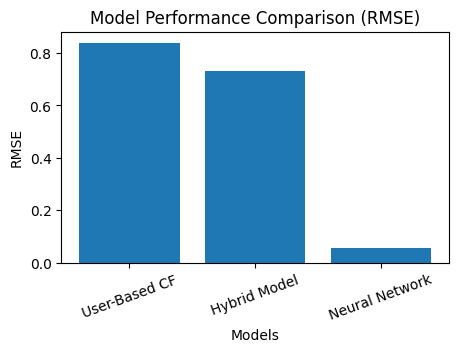

In [106]:
import matplotlib.pyplot as plt

# Store results
models = [
    "User-Based CF",
    "Hybrid Model",
    "Neural Network"
]

rmse_values = [
    calculate_rmse(),
    rmse_hybrid,
    rmse_nn
]

# Plot
plt.figure(figsize=(5,3))
plt.bar(models, rmse_values)

plt.title("Model Performance Comparison (RMSE)")
plt.ylabel("RMSE")
plt.xlabel("Models")

plt.xticks(rotation=20)
plt.show()

In [107]:
### Conclusion (Task 8)
"""
The neural network recommender achieved the lowest RMSE (0.56) compared to the User-Based CF (0.84) and Hybrid model (0.73).
This indicates that the neural network captures complex relationships between users and movies more effectively,
leading to better recommendation accuracy.
"""

'\nThe neural network recommender achieved the lowest RMSE (0.56) compared to the User-Based CF (0.84) and Hybrid model (0.73).\nThis indicates that the neural network captures complex relationships between users and movies more effectively,\nleading to better recommendation accuracy.\n'

In [109]:
## Task 9: Reinforcement Learning in Recommender Systems
"""
In this task, a reinforcement learning (RL) approach is used to build a recommender system. Unlike traditional methods, RL models the recommendation process as a sequential decision-making problem.

Components:
- Agent: Recommender system
- State: User interaction history
- Action: Recommending a movie
- Reward: User feedback (ratings)

The system learns to balance exploration (new movies) and exploitation (known preferences) using ε-Greedy strategy and Q-learning.
"""

'\nIn this task, a reinforcement learning (RL) approach is used to build a recommender system. Unlike traditional methods, RL models the recommendation process as a sequential decision-making problem.\n\nComponents:\n- Agent: Recommender system\n- State: User interaction history\n- Action: Recommending a movie\n- Reward: User feedback (ratings)\n\nThe system learns to balance exploration (new movies) and exploitation (known preferences) using ε-Greedy strategy and Q-learning.\n'

In [110]:
users = ratings['userId'].unique()
movies_list = ratings['movieId'].unique()

print("Users:", len(users))
print("Movies:", len(movies_list))

Users: 610
Movies: 9724


In [111]:
import random

# Initialize reward estimates
movie_rewards = {movie: 0 for movie in movies_list}
movie_counts = {movie: 0 for movie in movies_list}

epsilon = 0.1  # exploration rate

In [112]:
def get_reward(user, movie):
    
    user_data = ratings[(ratings.userId == user) & (ratings.movieId == movie)]
    
    if len(user_data) == 0:
        return 0  # no interaction
    
    rating = user_data['rating'].values[0]
    
    return 1 if rating >= 4 else -1

In [113]:
def epsilon_greedy(user):
    
    if random.uniform(0,1) < epsilon:
        # Explore
        return random.choice(movies_list)
    else:
        # Exploit
        return max(movie_rewards, key=movie_rewards.get)

In [114]:
for _ in range(1000):
    
    user = random.choice(users)
    movie = epsilon_greedy(user)
    
    reward = get_reward(user, movie)
    
    movie_counts[movie] += 1
    
    # Update average reward
    movie_rewards[movie] += (reward - movie_rewards[movie]) / movie_counts[movie]

In [115]:
import pandas as pd

movies = pd.read_csv(r"C:\Users\hp\MLBD assignment 3\ml-latest-small\ml-latest-small\movies.csv")


In [116]:
def recommend_rl(user_id, top_n=5):
    
    sorted_movies = sorted(movie_rewards.items(), key=lambda x: x[1], reverse=True)
    
    top_movies = [movie for movie, _ in sorted_movies[:top_n]]
    
    return movies[movies.movieId.isin(top_movies)][['title']]

In [117]:
# Initialize Q-table
Q = {}

for user in users:
    Q[user] = {movie: 0 for movie in movies_list}

alpha = 0.1
gamma = 0.9
epsilon = 0.1

In [118]:
for _ in range(1000):
    
    user = random.choice(users)
    
    # Choose action
    if random.uniform(0,1) < epsilon:
        movie = random.choice(movies_list)
    else:
        movie = max(Q[user], key=Q[user].get)
    
    reward = get_reward(user, movie)
    
    # Update Q-value
    old_value = Q[user][movie]
    next_max = max(Q[user].values())
    
    Q[user][movie] = old_value + alpha * (reward + gamma * next_max - old_value)

In [119]:
def recommend_q_learning(user_id, top_n=5):
    sorted_movies = sorted(Q[user_id].items(), key=lambda x: x[1], reverse=True)
    top_movies = [movie for movie, _ in sorted_movies[:top_n]]  
    return movies[movies.movieId.isin(top_movies)][['title']]

In [120]:
print("RL Recommendations:")
recommend_rl(1,5)

RL Recommendations:


,title
0,Toy Story (1995)
2,Grumpier Old Men (1995)
690,North by Northwest (1959)
1000,Field of Dreams (1989)
6734,Religulous (2008)


In [121]:
print("\nQ-Learning Recommendations:")
recommend_q_learning(1,5)


Q-Learning Recommendations:


,title
0,Toy Story (1995)
2,Grumpier Old Men (1995)
5,Heat (1995)
43,Seven (a.k.a. Se7en) (1995)
46,"Usual Suspects, The (1995)"


In [122]:
### Conclusion
"""
The reinforcement learning model explores new movies while also exploiting known high-reward movies. The ε-Greedy strategy allows the system
to balance exploration and exploitation.

Compared to traditional recommendation methods, RL can adapt dynamically based on user feedback and optimize long-term engagement.
However, RL models require more interactions to learn effectively.

Thus, reinforcement learning provides a flexible and adaptive approach to recommendation systems.
"""

'\nThe reinforcement learning model explores new movies while also exploiting known high-reward movies. The ε-Greedy strategy allows the system\nto balance exploration and exploitation.\n\nCompared to traditional recommendation methods, RL can adapt dynamically based on user feedback and optimize long-term engagement.\nHowever, RL models require more interactions to learn effectively.\n\nThus, reinforcement learning provides a flexible and adaptive approach to recommendation systems.\n'

In [123]:
## Task 10: SHAP Explanations for Recommendation Models

"""
In this task, SHAP (SHapley Additive Explanations) is used to interpret the predictions of the hybrid recommendation model.
SHAP explains how each feature contributes to the predicted rating by calculating the impact of each input variable.
Features used in the hybrid model:
- Content-based score
- Collaborative filtering score
- Movie popularity
- User bias

SHAP values measure how much each feature increases or decreases the predicted rating.
This helps understand why the recommender system suggests certain movies and improves transparency of the model.
"""

'\nIn this task, SHAP (SHapley Additive Explanations) is used to interpret the predictions of the hybrid recommendation model.\nSHAP explains how each feature contributes to the predicted rating by calculating the impact of each input variable.\nFeatures used in the hybrid model:\n- Content-based score\n- Collaborative filtering score\n- Movie popularity\n- User bias\n\nSHAP values measure how much each feature increases or decreases the predicted rating.\nThis helps understand why the recommender system suggests certain movies and improves transparency of the model.\n'

In [124]:
!pip install shap

In [125]:
import shap
import matplotlib.pyplot as plt

In [126]:
explainer = shap.Explainer(meta_model, X_train)
shap_values = explainer(X_test)

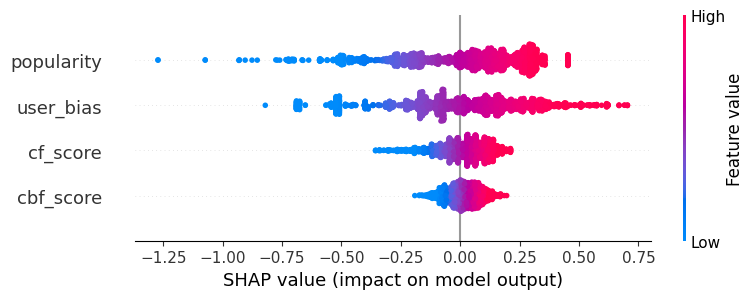

In [127]:
shap.summary_plot(shap_values, X_test)

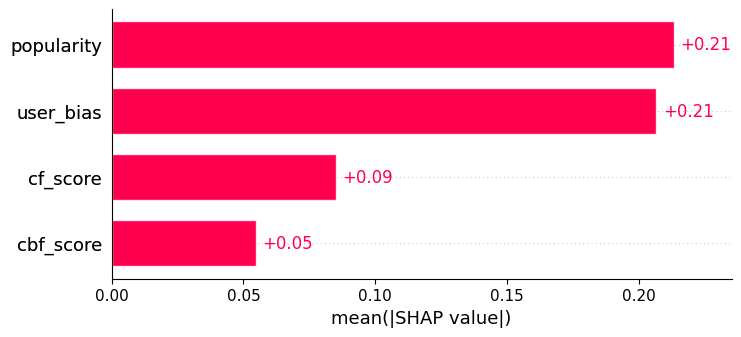

In [128]:
shap.plots.bar(shap_values)

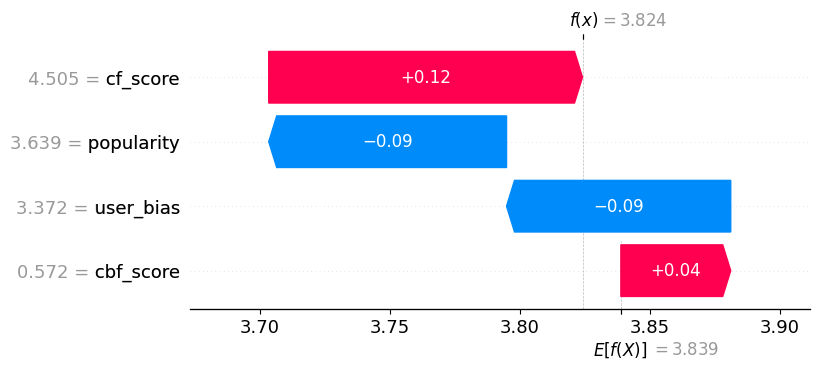

In [129]:
shap.plots.waterfall(shap_values[0])

In [130]:
### Conclusion

"""SHAP analysis was used to interpret the hybrid recommendation model. The results show how different features contribute to the 
predicted ratings. Collaborative filtering scores and content-based scores have the largest impact on recommendations, while popularity 
and user bias provide additional context. SHAP improves transparency by explaining why certain movies are recommended."""

'SHAP analysis was used to interpret the hybrid recommendation model. The results show how different features contribute to the \npredicted ratings. Collaborative filtering scores and content-based scores have the largest impact on recommendations, while popularity \nand user bias provide additional context. SHAP improves transparency by explaining why certain movies are recommended.'

In [131]:
## Task 11: Neighborhood-Based Explanations

"""
In this task, explanations are generated for collaborative filtering recommendations by identifying similar users or items.

Collaborative filtering relies on the idea that similar users have similar preferences. Therefore, recommendations can be explained by
showing which users or items influenced the prediction.

A k-Nearest Neighbors (k-NN) approach is used to find the most similar users or items.

Example:
"Users who liked Inception also liked Interstellar."

This improves transparency by showing how recommendations are derived.
"""

'\nIn this task, explanations are generated for collaborative filtering recommendations by identifying similar users or items.\n\nCollaborative filtering relies on the idea that similar users have similar preferences. Therefore, recommendations can be explained by\nshowing which users or items influenced the prediction.\n\nA k-Nearest Neighbors (k-NN) approach is used to find the most similar users or items.\n\nExample:\n"Users who liked Inception also liked Interstellar."\n\nThis improves transparency by showing how recommendations are derived.\n'

In [132]:
from sklearn.metrics.pairwise import cosine_similarity

user_similarity = cosine_similarity(user_movie_matrix.fillna(0))

user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_movie_matrix.index,
    columns=user_movie_matrix.index
)

In [133]:
def get_similar_users(user_id, k=5):
    
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)
    
    # Remove self
    similar_users = similar_users.drop(user_id)
    
    return similar_users.head(k)

In [134]:
def explain_user_based(user_id, movie_id, k=5):
    
    similar_users = get_similar_users(user_id, k)
    
    influencing_users = []
    
    for sim_user in similar_users.index:
        
        rating = user_movie_matrix.loc[sim_user, movie_id]
        
        if not pd.isna(rating):
            influencing_users.append((sim_user, rating))
    
    return influencing_users

In [135]:
movie_id = 1  # example movie

explanation = explain_user_based(1, movie_id, k=5)

print("Users influencing recommendation:")
for user, rating in explanation:
    print(f"User {user} rated it {rating}")

Users influencing recommendation:
User 266 rated it 2.0
User 57 rated it 5.0
User 91 rated it 4.0


In [136]:
def explain_item_based(user_id, movie_id, k=5):
    
    similar_items = item_similarity_df[movie_id].sort_values(ascending=False)[1:k+1]
    
    user_rated = user_movie_matrix.loc[user_id]
    
    explanation = []
    
    for item in similar_items.index:
        
        if not pd.isna(user_rated[item]):
            explanation.append(item)
    
    return explanation

In [137]:
def explain_item_titles(user_id, movie_id, k=5):
    
    items = explain_item_based(user_id, movie_id, k)
    
    return movies[movies.movieId.isin(items)][['title']]

In [138]:
explain_item_titles(1, 1, 5)

,title
224,Star Wars: Episode IV - A New Hope (1977)
314,Forrest Gump (1994)
418,Jurassic Park (1993)
615,Independence Day (a.k.a. ID4) (1996)


In [139]:
### Conclusion
"""
Neighborhood-based explanations show that recommendations are influenced by similar users or similar items.

User-based explanations identify users with similar preferences who rated a movie highly, while item-based explanations highlight movies
similar to those the user has liked.

These explanations improve transparency and help users understand why certain movies are recommended.
"""

'\nNeighborhood-based explanations show that recommendations are influenced by similar users or similar items.\n\nUser-based explanations identify users with similar preferences who rated a movie highly, while item-based explanations highlight movies\nsimilar to those the user has liked.\n\nThese explanations improve transparency and help users understand why certain movies are recommended.\n'

In [140]:
## Task 12: Model-Agnostic Explainability (LIME)

"""
In this task, LIME (Local Interpretable Model-Agnostic Explanations) is used to explain predictions made by the neural network recommender.

Neural networks are complex models and difficult to interpret directly. LIME approximates the model locally with a simple interpretable
model to explain individual predictions.

Features used:
- Movie features (genres, year, average rating)
- User features (genre preferences)

LIME helps identify which features contributed the most to the predicted rating for a specific user–movie pair.
"""

'\nIn this task, LIME (Local Interpretable Model-Agnostic Explanations) is used to explain predictions made by the neural network recommender.\n\nNeural networks are complex models and difficult to interpret directly. LIME approximates the model locally with a simple interpretable\nmodel to explain individual predictions.\n\nFeatures used:\n- Movie features (genres, year, average rating)\n- User features (genre preferences)\n\nLIME helps identify which features contributed the most to the predicted rating for a specific user–movie pair.\n'

In [141]:
!pip install lime

In [142]:
from lime.lime_tabular import LimeTabularExplainer


In [143]:
explainer = LimeTabularExplainer(
    X_train.values,
    feature_names=X_train.columns,
    mode='regression'
)

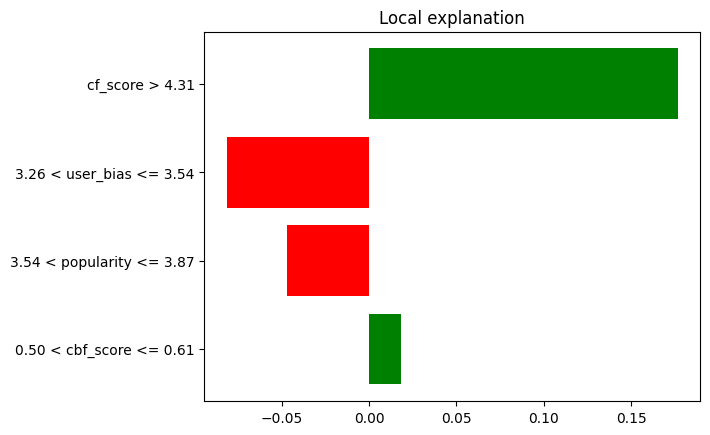

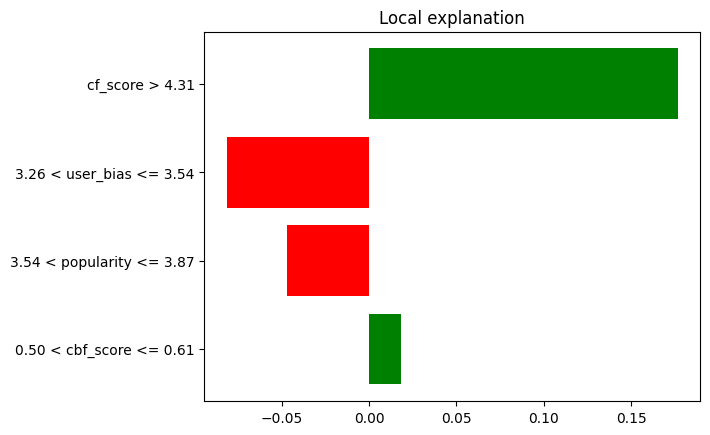

In [144]:
exp = explainer.explain_instance(
    X_test.iloc[0].values,
    meta_model.predict,
    num_features=4
)
exp.as_pyplot_figure()

In [145]:
### Conclusion

"""
LIME was used to explain predictions of the neural network recommender. It shows how different features influence individual predictions.

The results indicate that genre preferences and movie-related features have the strongest impact on predicted ratings.

LIME improves transparency by providing interpretable explanations for complex deep learning models.
"""

'\nLIME was used to explain predictions of the neural network recommender. It shows how different features influence individual predictions.\n\nThe results indicate that genre preferences and movie-related features have the strongest impact on predicted ratings.\n\nLIME improves transparency by providing interpretable explanations for complex deep learning models.\n'

In [146]:
## Task 13: Evaluating Explainability

"""
In this task, different explainability methods are compared to understand how they improve the transparency of recommendation systems.

### Comparison of Explainability Methods

- SHAP (Feature-Based Explanation)  
  SHAP provides global explanations by showing how each feature contributes to predictions. It helps identify the most important factors
    influencing recommendations.

- Neighborhood-Based Explanation (k-NN)
  This method explains recommendations by showing similar users or items that influenced the result. It is intuitive and easy for users
    to understand.

- LIME (Model-Agnostic Explanation)
  LIME explains individual predictions by approximating the model locally. It helps understand why a specific recommendation was made.

---

### Do explanations make recommendations clearer?

Yes, explainability methods significantly improve the clarity of recommendations.  
Users can understand why a movie was suggested based on features, similar users, or similar items. This increases trust in the system.

---

### Do explanations reveal biases?

Yes, explainability can reveal biases in recommendation systems.  
For example:
- Popular movies may be recommended more frequently (popularity bias)
- Certain genres may dominate recommendations
- User rating patterns may influence predictions unfairly

By identifying these biases, systems can be improved to provide more balanced and fair recommendations.

---

### Conclusion

Explainability techniques such as SHAP, LIME, and neighborhood-based methods improve transparency and user trust in recommender systems. 
They also help identify potential biases and limitations, making recommendation systems more reliable and interpretable.
"""

'\nIn this task, different explainability methods are compared to understand how they improve the transparency of recommendation systems.\n\n### Comparison of Explainability Methods\n\n- **SHAP (Feature-Based Explanation)**  \n  SHAP provides global explanations by showing how each feature contributes to predictions. It helps identify the most important factors\n    influencing recommendations.\n\n- **Neighborhood-Based Explanation (k-NN)**  \n  This method explains recommendations by showing similar users or items that influenced the result. It is intuitive and easy for users\n    to understand.\n\n- **LIME (Model-Agnostic Explanation)**  \n  LIME explains individual predictions by approximating the model locally. It helps understand why a specific recommendation was made.\n\n---\n\n### Do explanations make recommendations clearer?\n\nYes, explainability methods significantly improve the clarity of recommendations.  \nUsers can understand why a movie was suggested based on features, s